# TSAI Exercise Sheet 8

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import torch
import torch as tc
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from random import randint
from tqdm import trange

## Dataset

In [2]:
# No need to change anything here
class TimeSeriesDataset():
    def __init__(self, data, sequence_length=200, batch_size=16):
        self.X = torch.tensor(data, dtype=torch.float32)
        self.total_time_steps = self.X.shape[0]
        self.sequence_length = sequence_length
        self.batch_size = batch_size

    def __len__(self):
        return self.total_time_steps - self.sequence_length - 1

    def __getitem__(self, t):
        x = self.X[t:t+self.sequence_length, :]
        y = self.X[t+1:t+self.sequence_length+1, :]
        return x, y

    def sample_batch(self):
        X = []
        Y = []
        for _ in range(self.batch_size):
            idx = randint(0, len(self))
            x, y = self[idx]
            X.append(x)
            Y.append(y)

        return torch.stack(X), torch.stack(Y)

## Models

In [3]:
class PLRNN_Base(nn.Module):
    def __init__(self, M, P, N, device='cpu'):
        super(PLRNN_Base, self).__init__()

        # Device
        self.device = device

        # Initialize model dimensions
        self.M = M # latent dimension
        self.P = P # number of ReLUs
        self.N = N # readout dimension

        # Initialize model parameters A, W, h, B    
        self.A, self.W, self.h = self.initialize_AWh_random()
        self.B = self.init_uniform((self.N,self.M))

        self.to(self.device)
    
    def forward(self, z):
        Az = self.A * z
        Wphi = torch.matmul(torch.relu(z), self.W.T)
        z_t = Az + Wphi + self.h
        return z_t
    
    def initialize_AWh_random(self):
        #Randomly initialize A, W, h
        A = nn.Parameter(torch.diagonal(self.normalized_positive_definite(self.M),0).to(self.device)) # Create diagonal matrix A from normalized positive definite matrix
        W = nn.Parameter(torch.randn(self.M, self.M, device=self.device)*0.01) # Initialize weight matrix W with gaussian random numbers
        h = nn.Parameter(torch.zeros(self.M, device=self.device)) # Initialize bias vector h to zero
        return A, W, h
    
    def normalized_positive_definite(self,M):
        # Generate a normalized positive definite matrix
        R = np.random.randn(M, M).astype(np.float32)
        K = np.matmul(R.T, R) / M + np.eye(M)  # R'R ./ M + I
        eigenvalues = np.linalg.eigvals(K)
        lambda_max = np.max(np.abs(eigenvalues))
        return torch.tensor(K / lambda_max).float()
    
    def init_uniform(self, shape):
        # Initialize a tensor with a uniform distribution within range [-1/sqrt(M), 1/sqrt(M)]
        tensor = torch.empty(*shape, device=self.device)
        r = 1 / math.sqrt(shape[0])
        torch.nn.init.uniform_(tensor, -r, r)
        return nn.Parameter(tensor, requires_grad=True)

In [4]:
class PLRNN(PLRNN_Base):
    def __init__(self, M, N, device='cpu'):
        super(PLRNN, self).__init__(M=M, P=M, N=N, device=device)

    def forward(self, z):
        return super().forward(z)

In [5]:
class ALRNN(PLRNN_Base):
    def __init__(self, M, P, N, device='cpu'):
        super(ALRNN, self).__init__(M, P, N, device=device)

    def forward(self, z):
        return super().forward(z)

## Utilities

In [6]:
@torch.no_grad() # Disables gradient calculation to save memory and computation
def predict_free_sequence(model, x, T):
    """Predicts a sequence without updating model parameters (only for evaluation)"""
    
    b, N = x.size()

    Z = torch.empty(size=(T, b, model.M), device=x.device) # Initialize output tensor for the predicted sequence
    z = x @ model.B # Initialize first latent state
    z[:,0:N] = x

    # Predict sequence by passing previous state through the model
    for t in range(0, T):
        z = model(z)
        Z[t] = z

    return Z.permute(1, 0, 2)

In [7]:
def predict_sequence_using_stf(model, x, forcing_interval):
    """Predicts a sequence using sparse teacher forcing (only for training)"""
    
    x_ = x.permute(1, 0, 2) # Permute input to shape (sequence_length, batch_size, feature_dim)
    T, b, N = x_.shape # T: sequence length, b: batch size, N: feature dimension
    Z = torch.empty(size=(T, b, model.M), device=x.device)
    
    z =  x_[0] @ model.B # Initialize first latent state
    z = teacher_force(z, x_[0]) # Apply teacher forcing to the initial state

    # Generate sequence predictions
    for t in range(0, T):
        # Apply teacher forcing at regular intervals
        if (t % forcing_interval == 0) and (t > 0):
            z = teacher_force(z, x_[t])
            
        # Update the latent state using the model
        z = model(z)
        Z[t] = z
        
    return Z.permute(1, 0, 2)

def teacher_force(z, x):
    # Teacher force the state z
    N = x.size(-1)
    z[:, :N] = x
    return z

In [8]:
def plot_losses(losses):
    plt.rcParams["figure.figsize"] = (7,4)
    plt.rcParams.update({'font.size': 10})
    fig = plt.figure()

    ax = fig.add_subplot(111)
    ax.plot(losses,lw=3)
    ax.set_title('Training loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

In [9]:
def plot_trajectory(X_gen, X_test, T_gen):
    Blues = plt.cm.Blues
    plt.rcParams["lines.linewidth"] = .35
    plt.rcParams["figure.figsize"] = (7,5)
    plt.rcParams["lines.linewidth"] = 2.
    plt.rcParams.update({'font.size': 10})
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    xs = X_gen[:, 0]
    ys = X_gen[:, 1]
    zs = X_gen[:, 2]
    
    ax.plot(X_test[:T_gen, 0], X_test[:T_gen, 1], X_test[:T_gen, 2], color=Blues(0.9), label="Ground Truth")
    ax.plot(xs, ys, zs, color=Blues(0.6), alpha=1., label="Freely Generated")
    
    plt.legend(loc="upper left")
    plt.axis("off")
    plt.show()

## Training routine

In [10]:
def train(model, dataset, learning_rate, num_epochs, forcing_interval, batches_per_epoch=50):
    model.train() # Set model to training mode
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.RAdam(model.parameters(), lr=learning_rate)
    losses = []

    device = next(model.parameters()).device
    
    with trange(num_epochs, desc="Training Progress") as epochs:
        # Loop over batches in each epoch
        for e in epochs:
            epoch_losses = []
            
            for _ in range(batches_per_epoch):
                optimizer.zero_grad() # Reset gradients for the optimizer
                
                # Sample a batch of data from dataset (x: inputs, y: targets)
                x, y = dataset.sample_batch()
                x, y = x.to(device), y.to(device)

                # Predict sequence using teacher forcing
                zs = predict_sequence_using_stf(model, x, forcing_interval)
                predictions = zs[:,:,0:model.N]

                # Calculate loss using loss_fn
                loss = loss_fn(predictions, y)
                
                loss.backward()
                optimizer.step()
                epoch_losses.append(loss.item())
            
            # Compute and store average loss for the epoch
            average_epoch_loss = sum(epoch_losses) / len(epoch_losses)
            epochs.set_postfix(loss=average_epoch_loss)
            losses.append(average_epoch_loss)
    
    return losses

## 2a) Load / Plot Data

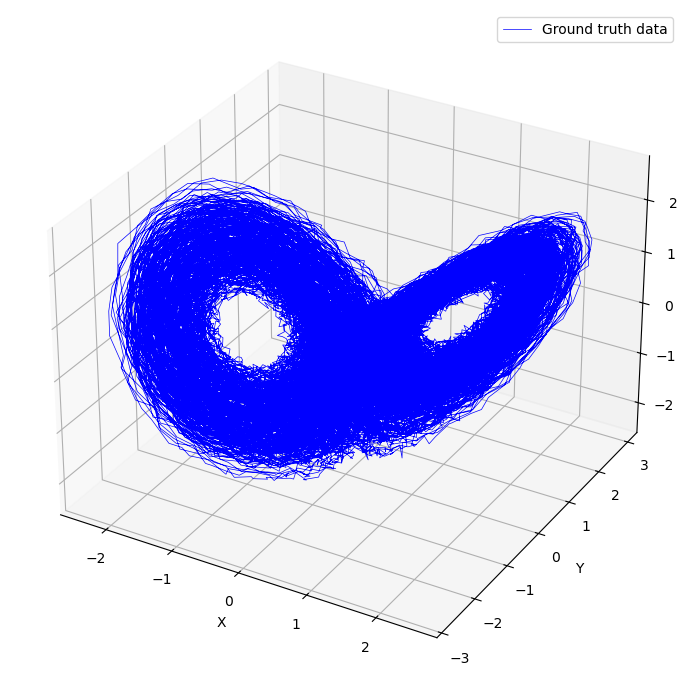

In [11]:
X_train = np.load("lorenz63_train.npy").astype(np.float32)[500:]
X_test = np.load("lorenz63_test.npy").astype(np.float32)[500:]
T_train, N = X_train.shape
T_test = X_test.shape[0]

def plot_lorenz(data, label, label2, prediction=None):
    
    x, y, z = data[:, 0], data[:, 1], data[:, 2]
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(x, y, z, lw=0.5, color='blue', label=label)
    if prediction is not None:
        ax.plot(prediction[:, 0], prediction[:, 1], prediction[:, 2], lw=0.8, color='red', label=label2)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()
    plt.tight_layout()

# Plotting 
plot_lorenz(X_train[:50000, :], 'Ground truth data', '')
plt.show()

### 2b) Training with standard RNN

In [12]:
from last_RNN import LatentRNN, train

In [25]:
# L1 regularization function
def l1_reg(parameters):
    
    l1_reg = alpha * sum(param.abs().sum() for param in parameters)

    return l1_reg

# Training parameters
alpha = 0.0001
observation_size = X_train.shape[1]
hidden_size = 300
learning_rate= 0.001
epochs = 100
alpha = 0.0002

# Training
data = torch.tensor(X_train)
model = LatentRNN(observation_size, hidden_size)
loss = train(model, learning_rate = learning_rate, moment=0, optimizer_function='ADAM', epochs=epochs, print_loss=False, batch_size=32, batch_sequence_length=240, reg = l1_reg, data = data)

In [26]:
# Compute MSE
h0 = tc.zeros(1, 1, model.latent_dim)
input_seq = data[:-1].unsqueeze(1)
target_seq = data[1:].unsqueeze(1)

# Run the model
with tc.no_grad():
    output_seq, _ = model(input_seq, h0) 

mse_loss = nn.MSELoss()
mse = mse_loss(output_seq, target_seq).item()
print(f"Mean Squared Error on full sequence: {mse:.6f}")

Mean Squared Error on full sequence: 0.005168


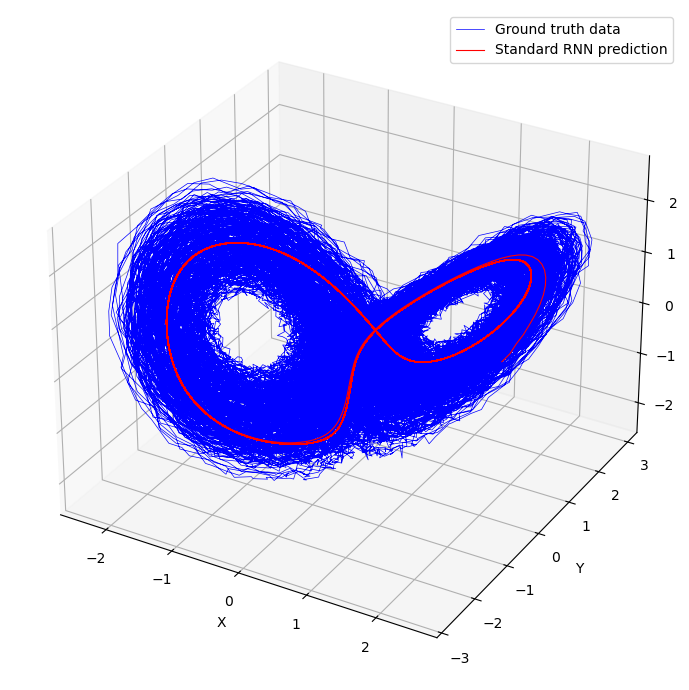

In [36]:
# Visual comparison
def autoregressive_rollout(model, warmup_seq, h0, rollout_steps):
    
    model.eval()
    warmup_length, obs_dim = warmup_seq.shape

    # Initial hidden state
    h = torch.zeros(1, 1, model.latent_dim)

    # Warm-up
    input_seq = warmup_seq[:-1].unsqueeze(1) 
    with torch.no_grad():
        output_seq, h = model(input_seq, h)

    # Start autoregressive rollout
    current_input = warmup_seq[-1].unsqueeze(0).unsqueeze(0)
    predictions = []

    with torch.no_grad():
        for _ in range(rollout_steps):
            output, h = model(current_input, h)
            x_hat = output.squeeze(0).squeeze(0)
            predictions.append(x_hat)
            current_input = output

    return torch.stack(predictions)

warmup_seq=data[:100]
rollout_steps = 100000
predicted_traj = autoregressive_rollout(model, warmup_seq, h0, rollout_steps)
plot_lorenz(X_train[:50000, :], 'Ground truth data', 'Standard RNN prediction', predicted_traj)
plt.show()

We see that the standard RNN model fails to capture the full dynamics of the Lorenz system. 

We see that the Standard RNN fails to reconstruct the Lorenz system properly.
## 2c) Initialize Model

In [95]:
# total number of latent units
M = 40 #TODO
# number of piecewise linear units
P = 40 #TODO
# number readout units
N = X_train.shape[-1]

model = ALRNN(M=M, P=P, N=N)

## Training Hyperparameters

In [96]:
batch_size = 32 #TODO: set batch size
sequence_length = 256 #TODO: set sequence length
forcing_interval = 16 #TODO: set forcing interval
num_epochs = 200 #TODO: set number of epochs
learning_rate = 1e-3

## Initialize Dataset

In [97]:
dataset = TimeSeriesDataset(X_train, sequence_length=sequence_length, batch_size=batch_size)

## Training

Training Progress: 100%|█████████| 200/200 [04:33<00:00,  1.37s/it, loss=0.0157]


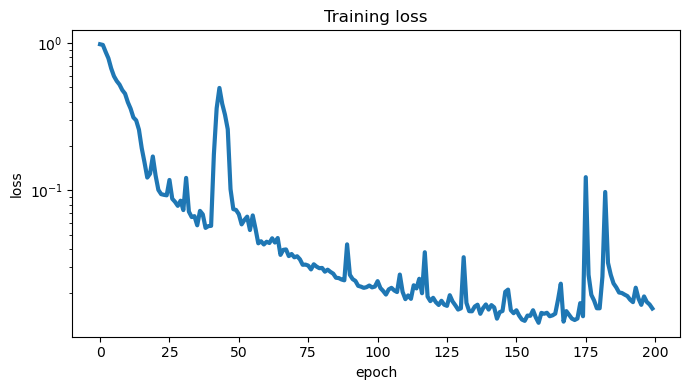

In [98]:
losses = train(model, dataset, learning_rate, num_epochs, forcing_interval, batches_per_epoch=50)
plot_losses(losses)

## Saving/Loading

In [99]:
torch.save(model.state_dict(), f"trained_model_M{M}_P{P}_N{N}.pt")

In [100]:
# model = ALRNN(M=M, P=P, N=N)
# model.load_state_dict(torch.load("trained_model.pt"))

## Analysis

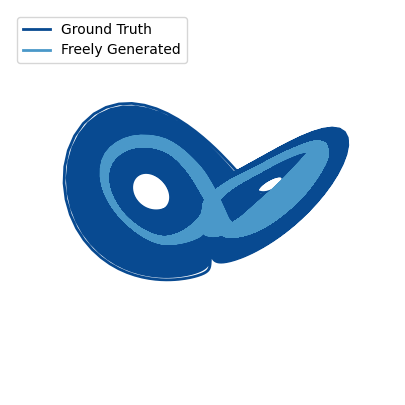

In [102]:
X_test_torch=torch.tensor(X_test[:]).unsqueeze(0)

T_gen = 100000 # Predicted sequence length
T_r = 1000 # Transient cutoff length
orbit = predict_free_sequence(model, X_test_torch[:,0,:],T_gen+T_r).detach().numpy()[0][T_r:,:]
plot_trajectory(orbit, X_test, T_gen)

### 2d)

In [83]:
def run_network(P):

    print(f'Results with P = {P}')
    M = 40 #TODO
    N = X_train.shape[-1]

    model = ALRNN(M=M, P=P, N=N)

    batch_size = 32 #TODO: set batch size
    sequence_length = 256 #TODO: set sequence length
    forcing_interval = 16 #TODO: set forcing interval
    num_epochs = 200 #TODO: set number of epochs
    learning_rate = 1e-3

    dataset = TimeSeriesDataset(X_train, sequence_length=sequence_length, batch_size=batch_size)

    losses = train(model, dataset, learning_rate, num_epochs, forcing_interval, batches_per_epoch=50)
    plot_losses(losses)

    X_test_torch=torch.tensor(X_test[:]).unsqueeze(0)

    T_gen = 100000 # Predicted sequence length
    T_r = 1000 # Transient cutoff length
    orbit = predict_free_sequence(model, X_test_torch[:,0,:],T_gen+T_r).detach().numpy()[0][T_r:,:]
    plot_trajectory(orbit, X_test, T_gen)

Results with P = 35


Training Progress: 100%|█████████| 200/200 [04:24<00:00,  1.32s/it, loss=0.0143]


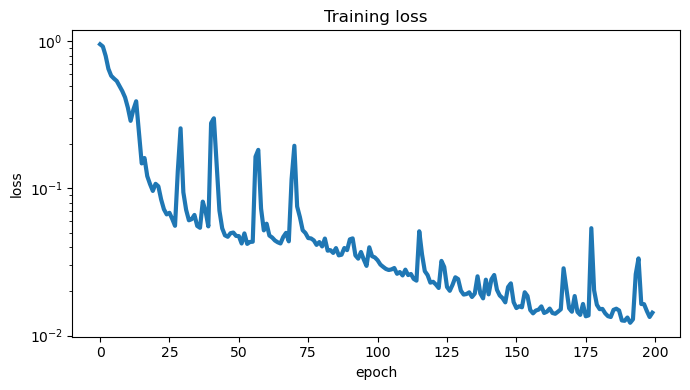

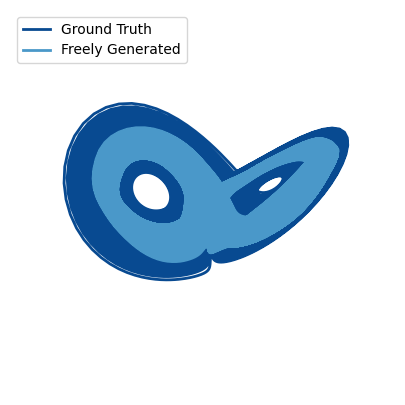

Results with P = 30


Training Progress: 100%|█████████| 200/200 [04:44<00:00,  1.42s/it, loss=0.0153]


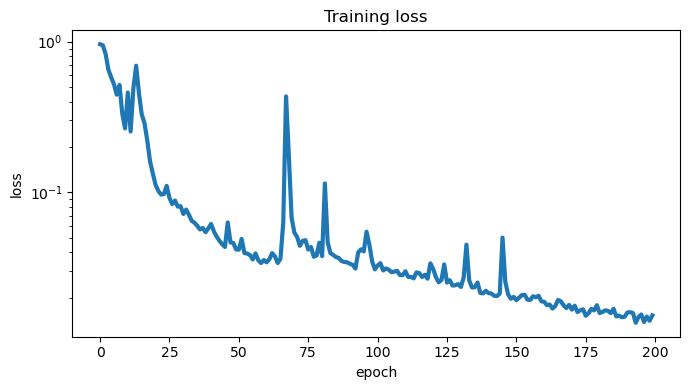

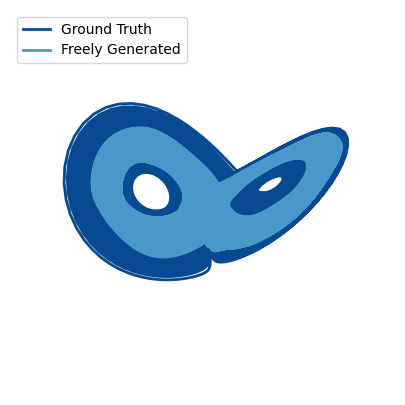

Results with P = 25


Training Progress: 100%|█████████| 200/200 [04:44<00:00,  1.42s/it, loss=0.0133]


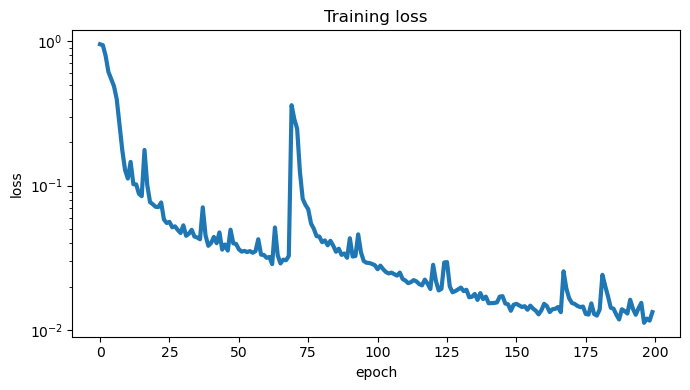

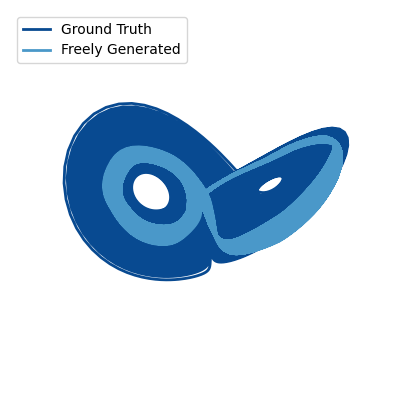

Results with P = 20


Training Progress: 100%|█████████| 200/200 [04:48<00:00,  1.44s/it, loss=0.0175]


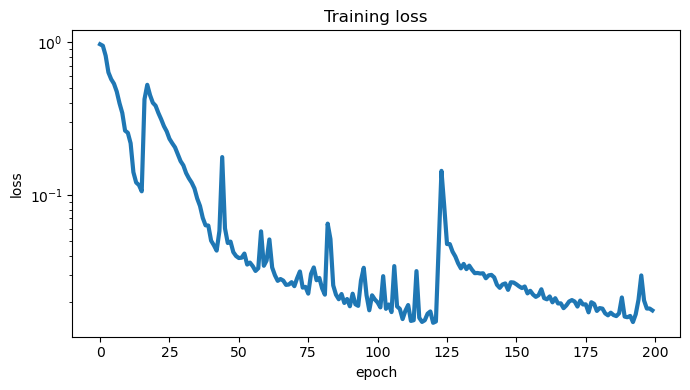

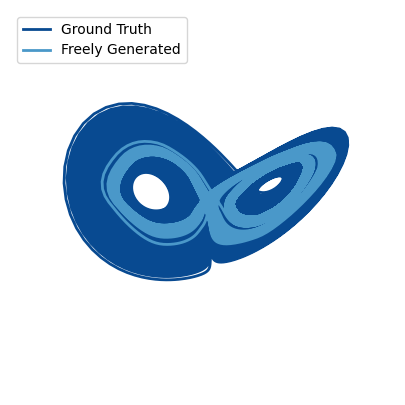

In [84]:
Ps = [35, 30, 25, 20]
for P in Ps:
    run_network(P)

We see that with lower P the quality of the reconstruction decreases. For P = 30, 35 the results are still fine but for P<30 their quality decreases significantly.

### 2e)

In [110]:
model = ALRNN(M=M, P=P, N=N)
model.load_state_dict(torch.load("trained_model_M40_P40_N3.pt"))

/var/folders/8z/kcqff85n4_gd_f_zryqx22vc0000gn/T/ipykernel_8889/2323863902.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("trained_mode

<All keys matched successfully>

In [111]:
@torch.no_grad()
def predict_free_latent_sequence(model, z0, T):
    b, M = z0.shape
    Z = torch.empty((T, b, M), device=z0.device)
    z = z0
    for t in range(T):
        z = model(z)
        Z[t] = z
    return Z.permute(1, 0, 2)

Perturbed z0 trajectory:


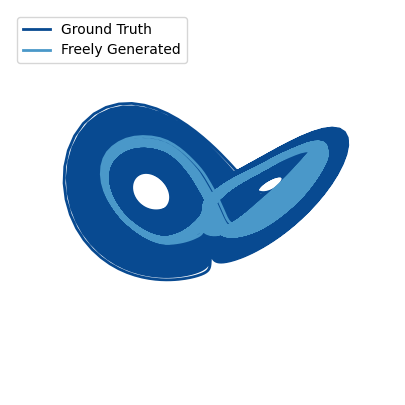

z0 trajectory:


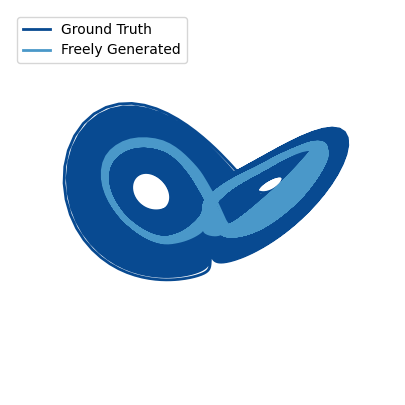

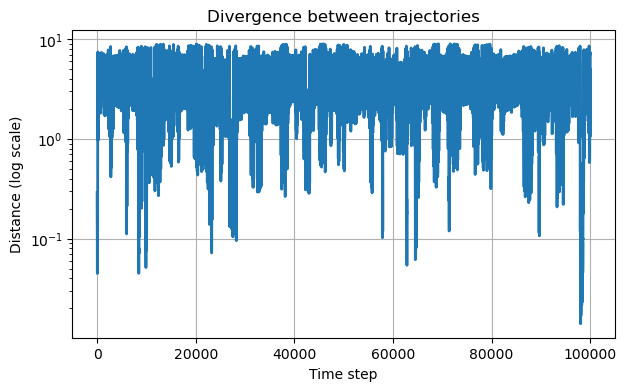

In [114]:
# Add small pertubation
eps = 1e-4
x0 = torch.tensor(X_test[:], dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    z0 = x0 @ model.B
    z0_p = z0 + torch.randn_like(z0) * eps

# Generate trajectory and plot
T_gen = 100000 
T_r = 1000 #
orbit_p = predict_free_latent_sequence(model, z0_p[:,0,:],T_gen+T_r).detach().numpy()[0][T_r:,:]
orbit = predict_free_latent_sequence(model, z0[:,0,:],T_gen+T_r).detach().numpy()[0][T_r:,:]
print('Perturbed z0 trajectory:')
plot_trajectory(orbit_p, X_test, T_gen)
print('z0 trajectory:')
plot_trajectory(orbit, X_test, T_gen)

# Distance over time
distances = np.linalg.norm(orbit - orbit_p, axis=1)
plt.figure(figsize=(7,4))
plt.semilogy(distances)
plt.title('Divergence between trajectories')
plt.xlabel('Time step')
plt.ylabel('Distance (log scale)')
plt.grid(True)
plt.show()

The trajectory look similar but not the same. There are some differences between them.